In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
base_path =
data_path =

stats = [] # to keep track of the number of valid and invalid saccades and fixations for each session
tol = 0.010

for folder in os.listdir(base_path):
    participant_path = os.path.join(base_path, folder)
    if not folder.startswith("preproc_"):
        continue
    participant_id = folder[-4:]

    if not os.path.isdir(data_path):
        continue
    blinks_path = f"{data_path}/blinkFiles"
    saccades_path = f"{data_path}/saccadeFiles/toUse"
    fixations_path = f"{data_path}/fixationFiles/toUse"

    try:
        df_blinks = pd.read_csv(f"{blinks_path}/blinks_{participant_id}.csv")
        df_saccades = pd.read_csv(f"{saccades_path}/saccades_{participant_id}.csv")
        df_fixations = pd.read_csv(f"{fixations_path}/fixations_{participant_id}.csv")
    except Exception as e:
        print('Failed to read', blinks_path, e)
        print('Failed to read', saccades_path, e)
        print('Failed to read', fixations_path, e)
        continue

    # Sort by timestamp (should be sorted already, but in case for proper merging)
    df_blinks = df_blinks.sort_values("start timestamp [ns]")
    df_saccades = df_saccades.sort_values("start timestamp [ns]")
    df_fixations = df_fixations.sort_values("start timestamp [ns]")

    ## function for filtering events within blinks (adding type valid or not valid to the events)
    def add_type(df_events, df_blinks):

        # add type column to events, default to 'valid'
        df_events['type'] = 'valid'

        # change type of events that fall within blinks to 'invalid'
        for _, blink in df_blinks.iterrows():
            start, end = blink['start timestamp [ns]'], blink['end timestamp [ns]']
            mask = (df_events['start timestamp [ns]'] >= start) & (df_events['start timestamp [ns]'] <= end)
            df_events.loc[mask, 'type'] = 'invalid'
        return df_events

    # clean df_saccades and df_fixations
    df_saccades_new = add_type(df_saccades, df_blinks)
    df_fixations_new = add_type(df_fixations, df_blinks)

    df_saccades_new['event_type'] = 'saccade'
    df_fixations_new['event_type'] = 'fixation'

    df_combined = pd.concat([df_saccades_new[df_saccades_new['type']=='valid'], df_fixations_new[df_fixations_new['type']=='valid']])
    df_combined = df_combined.sort_values("start timestamp [ns]").reset_index(drop=True)

    # --- Saccade → Saccade → remove FIRST ---
    mask_saccade = (
        (df_combined['event_type'] == 'saccade') &
        (df_combined['event_type'].shift(-1) == 'saccade')
    )

    # --- Fixation → Fixation → remove SECOND ---
    mask_fixation = (
        (df_combined['event_type'] == 'fixation') &
        (df_combined['event_type'].shift(1) == 'fixation')
    )

    # Apply invalidation
    df_combined.loc[mask_saccade, 'type'] = 'invalid'
    df_combined.loc[mask_fixation, 'type'] = 'invalid'

    # Collect indices
    found_saccade = df_combined.index[mask_saccade].tolist()
    found_fixation = df_combined.index[mask_fixation].tolist()

    df_fixations_final = df_combined[df_combined['event_type']=='fixation']
    df_saccades_final = df_combined[df_combined['event_type']=='saccade']

    stats.append({
        'participant_id': participant_id,
        'valid_saccades': df_saccades_final[df_saccades_final['type'] == 'valid'].shape[0],
        'invalid_saccades': df_saccades_final[df_saccades_final['type'] == 'invalid'].shape[0],
        'valid_fixations': df_fixations_final[df_fixations_final['type'] == 'valid'].shape[0],
        'invalid_fixations': df_fixations_final[df_fixations_final['type'] == 'invalid'].shape[0]
    })

    # save to a new folder
  #  new_path = os.path.join(data_path, 'new_fixations_saccades')
  #  if not os.path.exists(new_path):
  #      os.makedirs(new_path)
   # df_fixations_final.to_csv(os.path.join(new_path, 'fixations_' + participant_id + '.csv'), index=False)
  #  df_saccades_final.to_csv(os.path.join(new_path, 'saccades_' + participant_id + '.csv'), index=False)

# save summary on valid and invalid saccades and fixations to a file
#stats_df = pd.DataFrame(stats)
#stats_df.to_csv(os.path.join(base_path, 'saccades_fixations_stats.csv'), index=False)

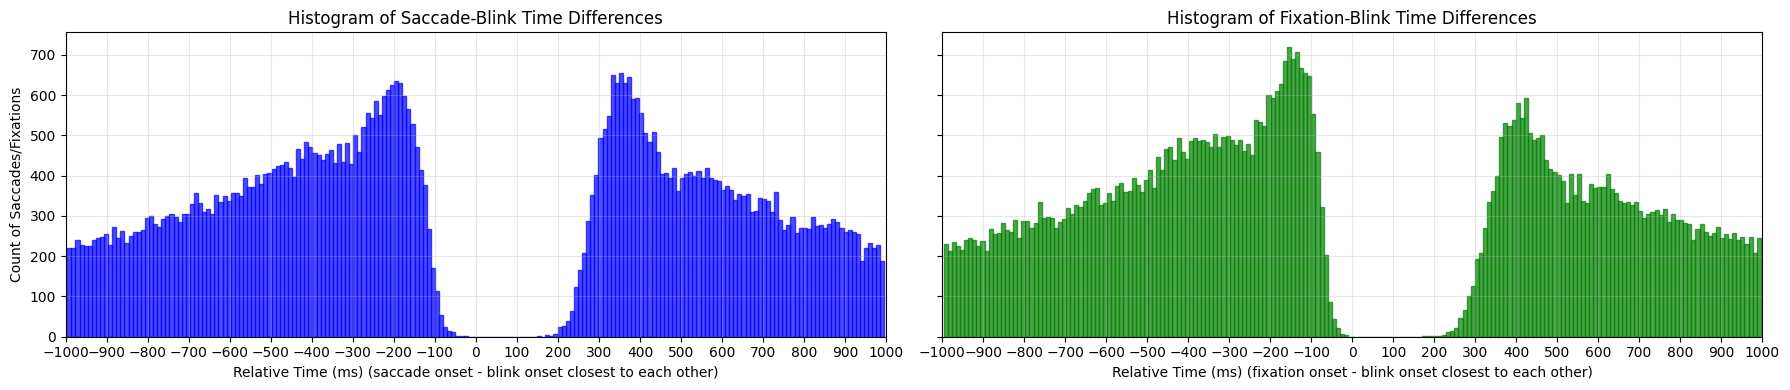

Histogram data saved.


In [ ]:
base_path =
data_path =

# initiate df for all sessions combined
df_blinks_saccades_all = pd.DataFrame()
df_blinks_fixations_all = pd.DataFrame()

for folder in os.listdir(base_path):
    participant_path = os.path.join(base_path, folder)
    if not folder.startswith("preproc_"):
        continue
    participant_id = folder[-4:]

    if not os.path.isdir(data_path):
        continue
    blinks_path = f"{data_path}/blinkFiles"
    saccades_path = f"{data_path}/new_fixations_saccades"
    fixations_path = f"{data_path}/new_fixations_saccades"

    try:
        df_blinks = pd.read_csv(f"{blinks_path}/blinks_{participant_id}.csv")
        df_saccades = pd.read_csv(f"{saccades_path}/saccades_{participant_id}.csv")
        df_fixations = pd.read_csv(f"{fixations_path}/fixations_{participant_id}.csv")
    except Exception as e:
        print('Failed to read', blinks_path, e)
        print('Failed to read', saccades_path, e)
        print('Failed to read', fixations_path, e)
        continue

    df_saccades = df_saccades[df_saccades['type'] == 'valid']
    df_fixations = df_fixations[df_fixations['type'] == 'valid']
    df_blinks['event_type'] = 'blink'

    # keep only common columns
    df_saccades = df_saccades[['start timestamp [ns]', 'end timestamp [ns]', 'duration [ms]','event_type']]
    df_fixations = df_fixations[['start timestamp [ns]', 'end timestamp [ns]', 'duration [ms]','event_type']]
    df_blinks = df_blinks[['start timestamp [ns]', 'end timestamp [ns]', 'duration [ms]','event_type']]

    # merge all of them and sort by starting timestamps
    df_all = pd.concat([df_blinks, df_saccades, df_fixations]).sort_values("start timestamp [ns]")

    # Calculate time difference between saccade start and closes to it blink start

    # Extract saccade and blink timestamps with indices
    saccades = df_all[df_all['event_type'] == 'saccade'][['start timestamp [ns]']].reset_index()
    fixations = df_all[df_all['event_type'] == 'fixation'][['start timestamp [ns]']].reset_index()
    blinks = df_all[df_all['event_type'] == 'blink'][['start timestamp [ns]']].reset_index()

    def nearest_blink(sacc_fix_ts):
        if len(blinks) == 0:
            return np.nan
        diffs = np.abs(sacc_fix_ts - blinks['start timestamp [ns]'])
        #diffs = np.abs(blinks['start timestamp [ns]'] - sacc_fix_ts)
        closest_idx = diffs.idxmin()
        return sacc_fix_ts - blinks.loc[closest_idx, 'start timestamp [ns]']
        #return blinks.loc[closest_idx, 'start timestamp [ns]'] - sacc_fix_ts

    # Apply to each saccade
    saccades['saccade-blink_ns'] = saccades['start timestamp [ns]'].apply(nearest_blink)
    fixations['fixation-blink_ns'] = fixations['start timestamp [ns]'].apply(nearest_blink)

    # Merge back to original df_all (matching on original index)
    df_all = df_all.merge(saccades[['start timestamp [ns]', 'saccade-blink_ns']],
                        on='start timestamp [ns]', how='left')  # NaN for non-saccades
    df_all = df_all.merge(fixations[['start timestamp [ns]', 'fixation-blink_ns']],
                        on='start timestamp [ns]', how='left')  # NaN for non-fixations

    # leave only difference of 1 second or less to reduce plot time
    df_all = df_all[(df_all['saccade-blink_ns'].abs() <= 1e9) | (df_all['fixation-blink_ns'].abs() <= 1e9)]


    # append to all sessions df
    df_blinks_saccades_all = pd.concat([df_blinks_saccades_all, df_all[df_all['event_type']=='saccade']], ignore_index=True)
    df_blinks_fixations_all = pd.concat([df_blinks_fixations_all, df_all[df_all['event_type']=='fixation']], ignore_index=True)


    ### histograms per session

    """fig, axes = plt.subplots(1, 2, figsize=(18,4), sharey=True)

    # Plot histogram for saccades vs blinks
    axes[0].hist(df_all[df_all['type']=='saccade']['saccade-blink_ns'] / 1e6, bins=200, alpha=0.7, color='blue', edgecolor='blue') # 10 ms bins
    axes[0].set_title(f'{folder} Histogram of Saccade-Blink Time Differences')
    axes[0].set_xlabel('Relative Time (ms) (saccade onset - blink onset closest to each other)')
    axes[0].set_ylabel('Count of Saccades/Fixations')
    axes[0].set_xlim(-1000, 1000)
    axes[0].set_xticks(np.arange(-1000, 1001, 200))
    axes[0].grid(True, alpha=0.3)

    # Plot histogram for fixations vs blinks
    axes[1].hist(df_all[df_all['type']=='fixation']['fixation-blink_ns'] / 1e6, bins=200, alpha=0.7, color='green', edgecolor='green') # 10 ms bins
    axes[1].set_title(f'{folder} Histogram of Fixation-Blink Time Differences')
    axes[1].set_xlabel('Relative Time (ms) (fixation onset - blink onset closest to each other)')
    axes[1].set_xlim(-1000, 1000)
    axes[1].set_xticks(np.arange(-1000, 1001, 200))
    axes[1].grid(True, alpha=0.3)"""


# histograms for all sessions combined
fig, axes = plt.subplots(1, 2, figsize=(18,4), sharey=True)

# Plot histogram for saccades vs blinks
axes[0].hist(df_blinks_saccades_all['saccade-blink_ns'] / 1e6, bins=200, alpha=0.7, color='blue', edgecolor='blue') # 10 ms bins
axes[0].set_title('Histogram of Saccade-Blink Time Differences')
axes[0].set_xlabel('Relative Time (ms) (saccade onset - blink onset closest to each other)')
axes[0].set_ylabel('Count of Saccades/Fixations')
axes[0].set_xlim(-1000, 1000)
axes[0].set_xticks(np.arange(-1000, 1001, 100))
axes[0].grid(True, alpha=0.3)

# Plot histogram for fixations vs blinks
axes[1].hist(df_blinks_fixations_all['fixation-blink_ns'] / 1e6, bins=200, alpha=0.7, color='green', edgecolor='green') # 10 ms bins
axes[1].set_title('Histogram of Fixation-Blink Time Differences')
axes[1].set_xlabel('Relative Time (ms) (fixation onset - blink onset closest to each other)')
axes[1].set_xlim(-1000, 1000)
axes[0].set_ylabel('Count of Saccades/Fixations')
axes[1].set_xticks(np.arange(-1000, 1001, 100))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save raw histogram data for MATLAB

# saccade-blink differences in ms
saccade_data_ms = df_blinks_saccades_all['saccade-blink_ns'] / 1e6

# fixation-blink differences in ms
fixation_data_ms = df_blinks_fixations_all['fixation-blink_ns'] / 1e6

# Save as CSV
saccade_data_ms.to_csv(
    f"{data_path}/saccade_blink_histogram_data.csv",
    index=False,
    header=['saccade_blink_ms']
)

fixation_data_ms.to_csv(
    f"{data_path}/fixation_blink_histogram_data.csv",
    index=False,
    header=['fixation_blink_ms']
)

print("Histogram data saved.")

# Save saccade data
df_blinks_saccades_all[
    ['participant_id', 'saccade-blink_ns']
].assign(
    saccade_blink_ms=lambda x: x['saccade-blink_ns'] / 1e6
).to_csv(
    f"{data_path}/saccade_blink_data_all_subjects.csv",
    index=False
)

# Save fixation data
df_blinks_fixations_all[
    ['participant_id', 'fixation-blink_ns']
].assign(
    fixation_blink_ms=lambda x: x['fixation-blink_ns'] / 1e6
).to_csv(
    f"{data_path}/fixation_blink_data_all_subjects.csv",
    index=False
)